In [1]:
import os
import torch

CKPT_DIR = r"C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\Baseline+ECA\Baseline+ECA(SamplerUNet++)GEMopt_Output"
CKPT_PATH = os.path.join(CKPT_DIR, "checkpoint_infer.pt")
assert os.path.exists(CKPT_PATH), f"Not found: {CKPT_PATH}"

DATASET2_DIR = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_2"
CSV_PATH     = os.path.join(DATASET2_DIR, "pneumothorax_normal_balanced_subset.csv")
IMG_DIR      = os.path.join(DATASET2_DIR, "pneumothorax_normal_balanced_images")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("CKPT_PATH:", CKPT_PATH)


device: cuda
CKPT_PATH: C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\Baseline+ECA\Baseline+ECA(SamplerUNet++)GEMopt_Output\checkpoint_infer.pt


In [2]:
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import torchvision

## Model

In [3]:
def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    # Only sample along batch dimension, broadcast others
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()  # binarize
    return x * random_tensor / keep_prob

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

In [4]:
class GRN(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)                # [N,1,1,C]
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)                 # [N,1,1,C]
        return self.gamma * (x * nx) + self.beta + x                     # [N,H,W,C]

In [5]:
class LayerNorm2d(nn.Module):
    def __init__(self, num_channels: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=1, keepdim=True)
        x = (x - mean) / torch.sqrt(var + self.eps)
        return self.weight.view(1, -1, 1, 1) * x + self.bias.view(1, -1, 1, 1)

In [6]:
class ECALayer(nn.Module):
    def __init__(self, channels: int, k_size: int = 3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=k_size,
            padding=(k_size - 1) // 2,
            bias=False,
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, H, W]
        y = self.avg_pool(x)                    # [B, C, 1, 1]
        y = y.squeeze(-1).transpose(-1, -2)     # [B, 1, C]
        y = self.conv(y)                        # [B, 1, C]
        y = self.sigmoid(y)
        y = y.transpose(-1, -2).unsqueeze(-1)   # [B, C, 1, 1]
        return x * y


In [7]:
class GeM(nn.Module):
    """
    Generalized Mean Pooling (GeM)
    output: [B, C]
    """
    def __init__(self, p: float = 3.0, eps: float = 1e-6, trainable: bool = True, relu_before: bool = True):
        super().__init__()
        self.eps = eps
        self.relu_before = relu_before

        if trainable:
            self.p = nn.Parameter(torch.ones(1) * p)
        else:
            self.register_buffer("p", torch.ones(1) * p)

    def forward(self, x):
        # x: [B, C, H, W]
        if self.relu_before:
            x = F.relu(x)

        # 为了数值稳定：p 做一下夹紧（可选但强烈建议）
        p = torch.clamp(self.p, 1.0, 6.0)

        x = x.clamp(min=self.eps).pow(p)
        x = x.mean(dim=(-1, -2)).pow(1.0 / p)   # [B, C]
        return x

In [8]:
class ConvNeXtV2Block(nn.Module):
    def __init__(
        self,
        dim: int,
        mlp_ratio: float = 4.0,
        drop_path: float = 0.0,
        layer_scale_init_value: float = 0.0,  
    ):
        super().__init__()
        # 7x7 depthwise convolution
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

        # Do LayerNorm in channels_last format
        self.norm = nn.LayerNorm(dim, eps=1e-6)

        hidden_dim = int(dim * mlp_ratio)
        self.pwconv1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.grn = GRN(hidden_dim)
        self.pwconv2 = nn.Linear(hidden_dim, dim)

        # LayerScale
        if layer_scale_init_value > 0:
            self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim))
        else:
            self.gamma = None

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x  # [N, C, H, W]

        x = self.dwconv(x)

        # NCHW -> NHWC
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)

        if self.gamma is not None:
            x = self.gamma.view(1, 1, 1, -1) * x

        # NHWC -> NCHW
        x = x.permute(0, 3, 1, 2)

        x = shortcut + self.drop_path(x)
        return x

In [9]:
class UpBlockUNetPP(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.conv1 = nn.Conv2d(in_ch + skip_ch, out_ch, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act   = nn.ReLU(inplace=True)

    def forward(self, x, skips=None):
        x = self.upsample(x)

        if skips is None:
            skips = []

        cat_list = [x]
        for s in skips:
            if s is None:
                continue
            if s.shape[-2:] != x.shape[-2:]:
                s = F.interpolate(s, size=x.shape[-2:], mode="bilinear", align_corners=False)
            cat_list.append(s)

        x = torch.cat(cat_list, dim=1)
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        return x

In [ ]:
class ConvNeXtV2Tiny(nn.Module):
    def __init__(
        self,
        in_chans: int = 3,
        num_classes: int = 1000,
        drop_path_rate: float = 0.0,
        layer_scale_init_value: float = 0.0, 
    ):
        super().__init__()

        # 4 deepths and dims for each stage
        depths = [3, 3, 9, 3]
        dims = [96, 192, 384, 768]

        self.downsample_layers = nn.ModuleList()
        self.stages = nn.ModuleList()

        # Constructing the stem: patch embedding with stride=4
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm2d(dims[0]),
        )
        self.downsample_layers.append(stem)

        # Constructing the blocks and downsampling layers for each stage
        total_blocks = sum(depths)
        dpr_values = torch.linspace(0, drop_path_rate, total_blocks).tolist()
        block_idx = 0

        for stage_idx in range(4):
            depth = depths[stage_idx]
            dim = dims[stage_idx]

            # Every stage begins with a downsampling layer (except the first)
            if stage_idx > 0:
                down = nn.Sequential(
                    LayerNorm2d(dims[stage_idx - 1]),
                    nn.Conv2d(dims[stage_idx - 1], dim, kernel_size=2, stride=2),
                )
                self.downsample_layers.append(down)

            blocks = []
            for i in range(depth):
                blocks.append(
                    ConvNeXtV2Block(
                        dim=dim,
                        mlp_ratio=4.0,
                        drop_path=dpr_values[block_idx + i],
                        layer_scale_init_value=layer_scale_init_value,
                    )
                )
            block_idx += depth

            self.stages.append(nn.Sequential(*blocks))

        # The last classification head: LN + Linear
        self.norm_head = nn.LayerNorm(dims[-1], eps=1e-6)
        self.head = (
            nn.Linear(dims[-1], num_classes) if num_classes > 0 else nn.Identity()
        )

    def forward_features(self, x):
        # Downsampling through stages
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)

        # Global average pooling and normalization
        x = x.mean(dim=[2, 3])
        x = self.norm_head(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)  # [N, num_classes]
        return x
    
class ConvNeXtV2TinyScratch(nn.Module):
    def __init__(
        self,
        in_chans: int = 1,
        n_classes: int = 1,
        drop_path_rate: float = 0.1,
        use_seg_guided: bool = True,  
    ):
        super().__init__()

        self.backbone = ConvNeXtV2Tiny(
            in_chans=in_chans,
            num_classes=n_classes,
            drop_path_rate=drop_path_rate,
            layer_scale_init_value=0.0,
        )

        # Channel dims at each stage of ConvNeXtV2Tiny
        dims = [96, 192, 384, 768]
        last_dim = dims[-1]   # The deepest 768

        # ===== ECA on deepest feature map =====
        self.eca4 = ECALayer(last_dim, k_size=3)

        # ===== Segmentation guidance =====
        self.use_seg_guided  = use_seg_guided   # ★ 改成用入参
        self.seg_guided_scale = 0.5             

        # ===== Classification head =====
        self.gem = GeM(p=3.0, eps=1e-6, trainable=True, relu_before=True)  # <-- 新增
        self.cls_head = nn.Linear(last_dim, n_classes)


        # ===== UNet++ Decoder (Nested) =====
        # level/channel:
        # x0_* : 1/4  -> 96
        # x1_* : 1/8  -> 192
        # x2_* : 1/16 -> 384
        # x3_* : 1/32 -> 768

        # j=1
        self.up_2_1 = UpBlockUNetPP(in_ch=768, skip_ch=384, out_ch=384)  # up(x3_0) + x2_0 -> x2_1
        self.up_1_1 = UpBlockUNetPP(in_ch=384, skip_ch=192, out_ch=192)  # up(x2_0) + x1_0 -> x1_1
        self.up_0_1 = UpBlockUNetPP(in_ch=192, skip_ch=96,  out_ch=96)   # up(x1_0) + x0_0 -> x0_1

        # j=2
        self.up_1_2 = UpBlockUNetPP(in_ch=384, skip_ch=192+192, out_ch=192)  # up(x2_1) + (x1_0,x1_1) -> x1_2
        self.up_0_2 = UpBlockUNetPP(in_ch=192, skip_ch=96+96,   out_ch=96)   # up(x1_1) + (x0_0,x0_1) -> x0_2

        # j=3
        self.up_0_3 = UpBlockUNetPP(in_ch=192, skip_ch=96+96+96, out_ch=96)  # up(x1_2) + (x0_0,x0_1,x0_2) -> x0_3

        self.up_half = UpBlockUNetPP(in_ch=96, skip_ch=0, out_ch=max(96 // 2, 32))  # 1/4 -> 1/2
        self.seg_head = nn.Conv2d(max(96 // 2, 32), 1, kernel_size=1)




    def forward_backbone_pyramid(self, x):
        """
        Return feature pyramid from backbone
        x1: 1/4,  x2: 1/8,  x3: 1/16, x4: 1/32
        """
        feats = []
        for i in range(4):
            x = self.backbone.downsample_layers[i](x)
            x = self.backbone.stages[i](x)

            if i == 3:
                x = self.eca4(x)    # x4: [B, 768, H/32, W/32]

            feats.append(x)
        return feats  # [x1, x2, x3, x4]


    def forward(self, x):
        # ---- Encoder ----
        x1, x2, x3, x4 = self.forward_backbone_pyramid(x)

        x0_0 = x1  # 1/4,  96
        x1_0 = x2  # 1/8,  192
        x2_0 = x3  # 1/16, 384
        x3_0 = x4  # 1/32, 768

        # j=1
        x2_1 = self.up_2_1(x3_0, [x2_0])
        x1_1 = self.up_1_1(x2_0, [x1_0])
        x0_1 = self.up_0_1(x1_0, [x0_0])

        # j=2
        x1_2 = self.up_1_2(x2_1, [x1_0, x1_1])
        x0_2 = self.up_0_2(x1_1, [x0_0, x0_1])

        # j=3
        x0_3 = self.up_0_3(x1_2, [x0_0, x0_1, x0_2])

        # 1/4 -> 1/2 for segmentation head
        d0 = self.up_half(x0_3, [])

        seg_logits = self.seg_head(d0)
        seg_logits = F.interpolate(seg_logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        # ---- Segmentation-guided Classification ----
        x4_for_cls = x4 

        if self.use_seg_guided:
            seg_prob = torch.sigmoid(seg_logits)

            seg_down = F.adaptive_avg_pool2d(seg_prob, output_size=x4.shape[-2:])

            x4_for_cls = x4 * (1.0 + self.seg_guided_scale * seg_down)

        # ---- Classification branch ----
        gap = self.gem(x4_for_cls)                # [B, C4] 
        gap = self.backbone.norm_head(gap)
        cls_logits = self.cls_head(gap)           # [B, 1]
        cls_logits = cls_logits.squeeze(1)        # [B]

        return cls_logits, seg_logits

model = ConvNeXtV2TinyScratch(
    in_chans=1,
    n_classes=1,
    drop_path_rate=0.1,
    use_seg_guided=False, 
).to(device)


## Load checkpoint_infer

In [ ]:
import torch
import torchvision.transforms as TV

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)

T_cal = float(ckpt["postprocess"]["temperature_T"])
thr   = float(ckpt["postprocess"]["cls_threshold"])
IMG_SIZE = int(ckpt["preprocess"]["img_size"])
mean = ckpt["preprocess"]["mean"]
std  = ckpt["preprocess"]["std"]

model = ConvNeXtV2TinyScratch(**ckpt["model_kwargs"]).to(device)
model.load_state_dict(ckpt["model_state"], strict=True)
model.eval()

# eval transforms (same as training)
eval_tfms = TV.Compose([
    TV.Resize((IMG_SIZE, IMG_SIZE)),
    TV.ToTensor(),
    TV.Normalize(mean=mean, std=std),
])

print("[OK] loaded checkpoint_infer.pt")
print("T_cal:", T_cal, "thr:", thr, "IMG_SIZE:", IMG_SIZE)


[OK] loaded checkpoint_infer.pt
T_cal: 0.8587129712104797 thr: 0.37 IMG_SIZE: 576


In [ ]:
ext_df = pd.read_csv(CSV_PATH)

ext_df["full_path"] = ext_df["Image Index"].apply(lambda x: os.path.join(IMG_DIR, str(x)))
ext_df["has_pneumo"] = (ext_df["Finding Labels"].astype(str).str.contains("Pneumothorax")).astype(int)

missing = (~ext_df["full_path"].apply(os.path.exists)).sum()
print("rows:", len(ext_df), "missing_files:", missing)

ext_df = ext_df[ext_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
print(ext_df["has_pneumo"].value_counts())
ext_df.head()


rows: 4388 missing_files: 0
has_pneumo
1    2194
0    2194
Name: count, dtype: int64


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],full_path,has_pneumo
0,00000013_033.png,Pneumothorax,11,13,56,M,PA,2946,2991,0.143,0.143,C:\Users\Steven\Desktop\Final Project\Datasets...,1
1,00000013_036.png,Pneumothorax,14,13,56,M,PA,2952,2968,0.143,0.143,C:\Users\Steven\Desktop\Final Project\Datasets...,1
2,00000013_039.png,Pneumothorax,17,13,56,M,PA,2992,2991,0.143,0.143,C:\Users\Steven\Desktop\Final Project\Datasets...,1
3,00000013_011.png,Pneumothorax,36,13,60,M,AP,3056,2544,0.139,0.139,C:\Users\Steven\Desktop\Final Project\Datasets...,1
4,00000013_012.png,Pneumothorax,37,13,60,M,AP,3056,2544,0.139,0.139,C:\Users\Steven\Desktop\Final Project\Datasets...,1


In [13]:
from torch.utils.data import Dataset, DataLoader

class ExternalClsDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("L")
        x = self.transform(img)
        y = int(row["has_pneumo"])
        return x, y

BATCH = 8
ext_ds = ExternalClsDataset(ext_df, transform=eval_tfms)
ext_dl = DataLoader(ext_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
len(ext_ds)


4388

In [15]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

from tqdm.auto import tqdm
import numpy as np
import torch

@torch.no_grad()
def infer_probs(model, loader, T_cal=1.0, desc="External inference"):
    ys, ps = [], []
    n_seen = 0

    pbar = tqdm(loader, total=len(loader), desc=desc)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)

        cls_logits, _seg_logits = model(xb)
        p = torch.sigmoid(cls_logits / T_cal)

        p_np = p.detach().cpu().float().numpy()
        y_np = yb.numpy()

        ps.append(p_np)
        ys.append(y_np)

        n_seen += len(y_np)
        pbar.set_postfix(
            n=n_seen,
            p_mean=float(np.mean(p_np)),
            pos_rate=float(np.mean(np.concatenate(ys))) if len(ys) > 0 else 0.0
        )

    return np.concatenate(ys), np.concatenate(ps)


def eval_binary(y_true, p, thr=0.5):
    y_pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "n": int(len(y_true)),
        "pos_rate": float(y_true.mean()),
        "roc_auc": float(roc_auc_score(y_true, p)) if len(np.unique(y_true)) == 2 else np.nan,
        "pr_auc": float(average_precision_score(y_true, p)) if len(np.unique(y_true)) == 2 else np.nan,
        "acc": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "spec": float(tn / (tn + fp + 1e-12)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "thr": float(thr), "T": float(T_cal)
    }

y_ext, p_ext = infer_probs(model, ext_dl, T_cal=T_cal)
metrics_ext = eval_binary(y_ext, p_ext, thr=thr)

print("=== External Generalization Metrics (NO TUNING) ===")
for k,v in metrics_ext.items():
    print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")


External inference:   0%|          | 0/549 [00:00<?, ?it/s]

=== External Generalization Metrics (NO TUNING) ===
n: 4388
pos_rate: 0.500000
roc_auc: 0.844432
pr_auc: 0.865139
acc: 0.757976
precision: 0.890345
recall: 0.588423
f1: 0.708562
spec: 0.927530
tn: 2035
fp: 159
fn: 903
tp: 1291
thr: 0.370000
T: 0.858713


In [16]:
import os

SAVE_DIR = r"C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\Generalization_check\result"
os.makedirs(SAVE_DIR, exist_ok=True)

pred_df = ext_df.copy()
pred_df["p_calibrated"] = p_ext
pred_df["y_pred"] = (p_ext >= thr).astype(int)

save_path = os.path.join(SAVE_DIR, "external_predictions.csv")
pred_df.to_csv(save_path, index=False)

print("[Saved]", save_path)
pred_df.head()


[Saved] C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\Generalization_check\result\external_predictions.csv


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],full_path,has_pneumo,p_calibrated,y_pred
0,00000013_033.png,Pneumothorax,11,13,56,M,PA,2946,2991,0.143,0.143,C:\Users\Steven\Desktop\Final Project\Datasets...,1,0.864298,1
1,00000013_036.png,Pneumothorax,14,13,56,M,PA,2952,2968,0.143,0.143,C:\Users\Steven\Desktop\Final Project\Datasets...,1,0.980750,1
2,00000013_039.png,Pneumothorax,17,13,56,M,PA,2992,2991,0.143,0.143,C:\Users\Steven\Desktop\Final Project\Datasets...,1,0.960103,1
3,00000013_011.png,Pneumothorax,36,13,60,M,AP,3056,2544,0.139,0.139,C:\Users\Steven\Desktop\Final Project\Datasets...,1,0.942828,1
4,00000013_012.png,Pneumothorax,37,13,60,M,AP,3056,2544,0.139,0.139,C:\Users\Steven\Desktop\Final Project\Datasets...,1,0.977351,1


In [17]:
import json
with open(os.path.join(SAVE_DIR, "external_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_ext, f, ensure_ascii=False, indent=2)
print("[Saved]", os.path.join(SAVE_DIR, "external_metrics.json"))


[Saved] C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\Generalization_check\result\external_metrics.json


In [ ]:
def eval_by_group(df, col):
    rows = []
    for g, sub in df.groupby(col):
        y = sub["has_pneumo"].to_numpy().astype(int)
        p = sub["p_calibrated"].to_numpy().astype(float)
        m = eval_binary(y, p, thr=thr)
        m[col] = g
        rows.append(m)
    return pd.DataFrame(rows).sort_values("n", ascending=False)

if "View Position" in pred_df.columns:
    display(eval_by_group(pred_df, "View Position")[["View Position","n","roc_auc","pr_auc","f1","recall","spec","precision"]])

if "Patient Sex" in pred_df.columns:
    display(eval_by_group(pred_df, "Patient Sex")[["Patient Sex","n","roc_auc","pr_auc","f1","recall","spec","precision"]])


,View Position,n,roc_auc,pr_auc,f1,recall,spec,precision
1,PA,2953,0.850493,0.875261,0.711961,0.581009,0.946786,0.919118
0,AP,1435,0.835684,0.847201,0.701518,0.604651,0.890228,0.835341


,Patient Sex,n,roc_auc,pr_auc,f1,recall,spec,precision
1,M,2253,0.897867,0.891572,0.782755,0.698302,0.931310,0.890446
0,F,2135,0.792620,0.849754,0.637244,0.496228,0.922505,0.890226


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def sweep_thresholds(y, p, thresholds=np.linspace(0.01, 0.99, 99)):
    rows = []
    for t in thresholds:
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
        rows.append({
            "t": float(t),
            "acc": accuracy_score(y, yhat),
            "precision": precision_score(y, yhat, zero_division=0),
            "recall": recall_score(y, yhat, zero_division=0),
            "f1": f1_score(y, yhat, zero_division=0),
            "spec": tn / (tn + fp + 1e-12),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        })
    return pd.DataFrame(rows)

df_sweep = sweep_thresholds(y_ext, p_ext)
display(df_sweep.sort_values("f1", ascending=False).head(10))   
display(df_sweep[df_sweep["recall"]>=0.80].sort_values("precision", ascending=False).head(10))  # 看达到 recall>=0.8 的阈值点


,t,acc,precision,recall,f1,spec,tp,fp,fn,tn
4,0.05,0.756609,0.732837,0.807657,0.768430,0.705561,1772,646,422,1548
5,0.06,0.762990,0.754185,0.780310,0.767025,0.745670,1712,558,482,1636
3,0.04,0.741568,0.702910,0.836828,0.764045,0.646308,1836,776,358,1418
6,0.07,0.763218,0.764060,0.761623,0.762840,0.764813,1671,516,523,1678
10,0.11,0.773929,0.810434,0.715132,0.759806,0.832726,1569,367,625,1827
8,0.09,0.767548,0.786621,0.734275,0.759547,0.800820,1611,437,583,1757
9,0.10,0.770738,0.798793,0.723792,0.759445,0.817685,1588,400,606,1794
7,0.08,0.763218,0.774086,0.743391,0.758428,0.783045,1631,476,563,1718
11,0.12,0.772106,0.814542,0.704649,0.755621,0.839562,1546,352,648,1842
12,0.13,0.771422,0.819303,0.696445,0.752895,0.846399,1528,337,666,1857


,t,acc,precision,recall,f1,spec,tp,fp,fn,tn
4,0.05,0.756609,0.732837,0.807657,0.768430,0.705561,1772,646,422,1548
3,0.04,0.741568,0.702910,0.836828,0.764045,0.646308,1836,776,358,1418
2,0.03,0.701459,0.647333,0.885141,0.747786,0.517776,1942,1058,252,1136
1,0.02,0.611668,0.566903,0.946217,0.709016,0.277119,2076,1586,118,608
0,0.01,0.509344,0.504722,0.998633,0.670543,0.020055,2191,2150,3,44


In [20]:
pred_df = ext_df.copy()
pred_df["p"] = p_ext
pred_df["y_pred"] = (p_ext >= thr).astype(int)

fn_df = pred_df[(pred_df["has_pneumo"]==1) & (pred_df["y_pred"]==0)].sort_values("p").head(30)
fp_df = pred_df[(pred_df["has_pneumo"]==0) & (pred_df["y_pred"]==1)].sort_values("p", ascending=False).head(30)

fn_df[["Image Index","p","full_path"]].head(10), fp_df[["Image Index","p","full_path"]].head(10)


(           Image Index         p  \
 1423  00019093_002.png  0.009387   
 842   00011423_003.png  0.009517   
 764   00010316_002.png  0.009643   
 252   00002924_001.png  0.010067   
 208   00002469_005.png  0.010312   
 1609  00021611_002.png  0.010931   
 314   00003513_007.png  0.010935   
 841   00011423_002.png  0.011619   
 1484  00020188_000.png  0.011650   
 526   00007459_000.png  0.011728   
 
                                               full_path  
 1423  C:\Users\Steven\Desktop\Final Project\Datasets...  
 842   C:\Users\Steven\Desktop\Final Project\Datasets...  
 764   C:\Users\Steven\Desktop\Final Project\Datasets...  
 252   C:\Users\Steven\Desktop\Final Project\Datasets...  
 208   C:\Users\Steven\Desktop\Final Project\Datasets...  
 1609  C:\Users\Steven\Desktop\Final Project\Datasets...  
 314   C:\Users\Steven\Desktop\Final Project\Datasets...  
 841   C:\Users\Steven\Desktop\Final Project\Datasets...  
 1484  C:\Users\Steven\Desktop\Final Project\Datasets...  
 

In [ ]:
import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

SAVE_DIR = r"C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\Generalization_check\result"
os.makedirs(SAVE_DIR, exist_ok=True)

pred_df = ext_df.copy()
pred_df["p_calibrated"] = p_ext
pred_df["y_pred_no_tuning"] = (pred_df["p_calibrated"] >= thr).astype(int) 

assert "has_pneumo" in pred_df.columns
assert "p_calibrated" in pred_df.columns

internal_thr = float(thr)  # thr=0.37（from checkpoint_infer.pt）

def eval_at_threshold(y, p, t: float):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    return {
        "t": float(t),
        "n": int(len(y)),
        "pos_rate": float(y.mean()),
        "acc": float(accuracy_score(y, yhat)),
        "precision": float(precision_score(y, yhat, zero_division=0)),
        "recall": float(recall_score(y, yhat, zero_division=0)),
        "f1": float(f1_score(y, yhat, zero_division=0)),
        "spec": float(tn / (tn + fp + 1e-12)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def sweep_thresholds(y, p, thresholds):
    rows = []
    for t in thresholds:
        rows.append(eval_at_threshold(y, p, float(t)))
    return pd.DataFrame(rows)

def pick_threshold(calib_df, mode="max_f1", target_recall=0.80):
    """
    mode:
      - "max_f1": calib 上找 F1 最大的阈值
      - "recall_at_least": calib 上先满足 recall>=target_recall，再在其中选 precision 最大
    """
    y = calib_df["has_pneumo"].to_numpy().astype(int)
    p = calib_df["p_calibrated"].to_numpy().astype(float)
    ts = np.linspace(0.01, 0.99, 99)

    df = sweep_thresholds(y, p, ts)

    if mode == "max_f1":
        best = df.loc[df["f1"].idxmax()].to_dict()
    elif mode == "recall_at_least":
        cand = df[df["recall"] >= target_recall].copy()
        if len(cand) == 0:
            best = df.loc[df["recall"].idxmax()].to_dict()
            best["note"] = f"No threshold reached recall>={target_recall}; fallback to max-recall."
        else:
            best = cand.loc[cand["precision"].idxmax()].to_dict()
    else:
        raise ValueError("mode must be 'max_f1' or 'recall_at_least'")

    return float(best["t"]), df, best

def auc_metrics(df):
    y = df["has_pneumo"].to_numpy().astype(int)
    p = df["p_calibrated"].to_numpy().astype(float)
    out = {}
    if len(np.unique(y)) == 2:
        out["roc_auc"] = float(roc_auc_score(y, p))
        out["pr_auc"]  = float(average_precision_score(y, p))
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"]  = np.nan
    return out

# ====== 4) NO TUNING
y_all = pred_df["has_pneumo"].to_numpy().astype(int)
p_all = pred_df["p_calibrated"].to_numpy().astype(float)

no_tuning_all = eval_at_threshold(y_all, p_all, internal_thr) | auc_metrics(pred_df)
print("\n[NO TUNING | External ALL]")
print(no_tuning_all)

# ====== 5)  external-calib / external-test  ======
calib_df, test_df = train_test_split(
    pred_df,
    test_size=0.8,              
    random_state=42,
    stratify=pred_df["has_pneumo"]
)
print("\nSplit:", len(calib_df), "calib |", len(test_df), "test")

# ====== 6) 只在 external-calib ======
t_f1, sweep_df, best_calib_f1 = pick_threshold(calib_df, mode="max_f1")

t_r80, sweep_df2, best_calib_r80 = pick_threshold(calib_df, mode="recall_at_least", target_recall=0.80)

print("\n[External-Calib best | max F1] t =", t_f1, best_calib_f1)
print("\n[External-Calib best | Recall>=0.80 (max precision)] t =", t_r80, best_calib_r80)

# ====== 7)  external-test ）======
y_test = test_df["has_pneumo"].to_numpy().astype(int)
p_test = test_df["p_calibrated"].to_numpy().astype(float)

no_tuning_test = eval_at_threshold(y_test, p_test, internal_thr) | auc_metrics(test_df)
tuned_f1_test  = eval_at_threshold(y_test, p_test, t_f1) | auc_metrics(test_df)
tuned_r80_test = eval_at_threshold(y_test, p_test, t_r80) | auc_metrics(test_df)

print("\n[NO TUNING | External TEST] (t=internal_thr)")
print(no_tuning_test)

print("\n[TUNED on External-Calib | External TEST] (t=maxF1 on calib)")
print(tuned_f1_test)

print("\n[TUNED on External-Calib | External TEST] (t=Recall>=0.80 on calib)")
print(tuned_r80_test)

sweep_path = os.path.join(SAVE_DIR, "external_calib_threshold_sweep.csv")
sweep_df.to_csv(sweep_path, index=False)

summary = {
    "no_tuning_all": no_tuning_all,
    "split": {"calib_n": int(len(calib_df)), "test_n": int(len(test_df)), "random_state": 42},
    "internal_thr": internal_thr,
    "external_calib_best_maxf1": {"t": t_f1, "calib_metrics": best_calib_f1},
    "external_calib_best_recall>=0.80": {"t": t_r80, "calib_metrics": best_calib_r80},
    "no_tuning_test": no_tuning_test,
    "tuned_maxf1_test": tuned_f1_test,
    "tuned_recall>=0.80_test": tuned_r80_test,
}
summary_path = os.path.join(SAVE_DIR, "external_generalization_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

test_save = test_df.copy()
test_save.to_csv(os.path.join(SAVE_DIR, "external_test_predictions.csv"), index=False)

print("\n[Saved]", sweep_path)
print("[Saved]", summary_path)
print("[Saved]", os.path.join(SAVE_DIR, "external_test_predictions.csv"))


[NO TUNING | External ALL]
{'t': 0.37, 'n': 4388, 'pos_rate': 0.5, 'acc': 0.7579762989972653, 'precision': 0.8903448275862069, 'recall': 0.5884229717411121, 'f1': 0.7085620197585072, 'spec': 0.9275296262534181, 'tn': 2035, 'fp': 159, 'fn': 903, 'tp': 1291, 'roc_auc': 0.8444321506653182, 'pr_auc': 0.8651390801403076}

Split: 877 calib | 3511 test

[External-Calib best | max F1] t = 0.09999999999999999 {'t': 0.09999999999999999, 'n': 877.0, 'pos_rate': 0.500570125427594, 'acc': 0.7833523375142531, 'precision': 0.8200514138817481, 'recall': 0.7266514806378133, 'f1': 0.7705314009661836, 'spec': 0.8401826484018245, 'tn': 368.0, 'fp': 70.0, 'fn': 120.0, 'tp': 319.0}

[External-Calib best | Recall>=0.80 (max precision)] t = 0.05 {'t': 0.05, 'n': 877.0, 'pos_rate': 0.500570125427594, 'acc': 0.7491448118586089, 'precision': 0.7248459958932238, 'recall': 0.8041002277904328, 'f1': 0.7624190064794817, 'spec': 0.6940639269406377, 'tn': 304.0, 'fp': 134.0, 'fn': 86.0, 'tp': 353.0}

[NO TUNING | Ext

## Diagrams

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, roc_curve, precision_recall_curve, auc
)
from sklearn.calibration import calibration_curve

SAVE_DIR = r"C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\Generalization_check\result"
os.makedirs(SAVE_DIR, exist_ok=True)

def plot_confusion_matrix(y_true, p, thr, title, save_path):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    y_pred = (p >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fig = plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i,j]), ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()
    plt.close(fig)

    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

def plot_roc(y_true, p, title, save_path):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    fpr, tpr, _ = roc_curve(y_true, p)
    roc_auc = auc(fpr, tpr)

    fig = plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()
    plt.close(fig)

def plot_pr(y_true, p, title, save_path):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    prec, rec, _ = precision_recall_curve(y_true, p)
    pr_auc = auc(rec, prec)

    fig = plt.figure(figsize=(5,4))
    plt.plot(rec, prec, label=f"PR-AUC={pr_auc:.3f}")
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()
    plt.close(fig)

def plot_prob_hist(y_true, p, title, save_path, bins=30):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    p_pos = p[y_true==1]
    p_neg = p[y_true==0]

    fig = plt.figure(figsize=(6,4))
    plt.hist(p_neg, bins=bins, alpha=0.6, label=f"Neg (n={len(p_neg)})")
    plt.hist(p_pos, bins=bins, alpha=0.6, label=f"Pos (n={len(p_pos)})")
    plt.title(title)
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()
    plt.close(fig)

def plot_calibration(y_true, p, title, save_path, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="uniform")

    fig = plt.figure(figsize=(5,4))
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0,1], [0,1], linestyle="--", label="Perfectly calibrated")
    plt.title(title)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.legend(loc="upper left")
    plt.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()
    plt.close(fig)

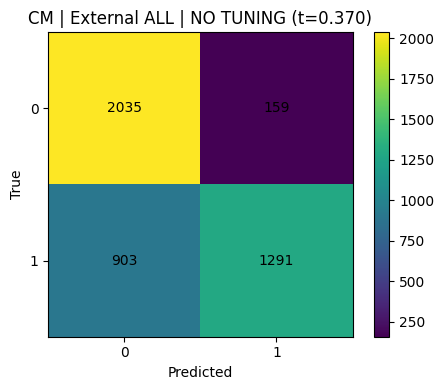

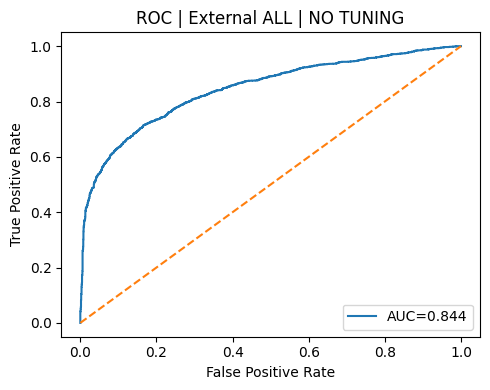

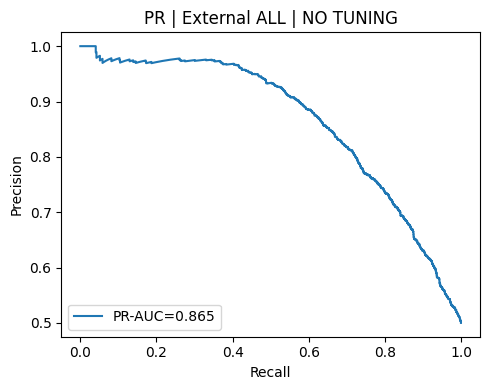

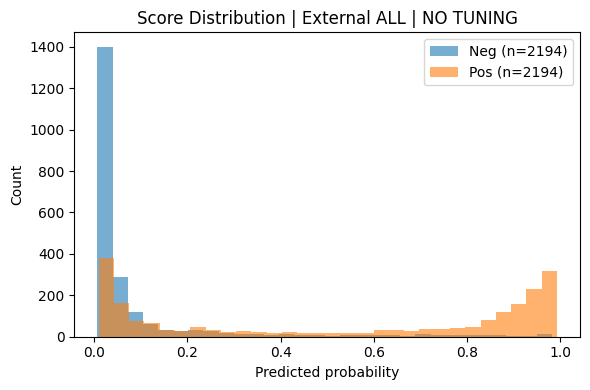

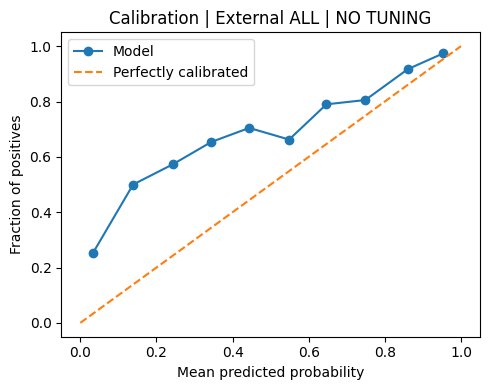

In [24]:
prefix = "external_all_no_tuning"

plot_confusion_matrix(
    y_ext, p_ext, thr,
    title=f"CM | External ALL | NO TUNING (t={thr:.3f})",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_cm.png")
)

plot_roc(
    y_ext, p_ext,
    title="ROC | External ALL | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_roc.png")
)

plot_pr(
    y_ext, p_ext,
    title="PR | External ALL | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_pr.png")
)

plot_prob_hist(
    y_ext, p_ext,
    title="Score Distribution | External ALL | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_score_hist.png")
)

plot_calibration(
    y_ext, p_ext,
    title="Calibration | External ALL | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_calibration.png")
)

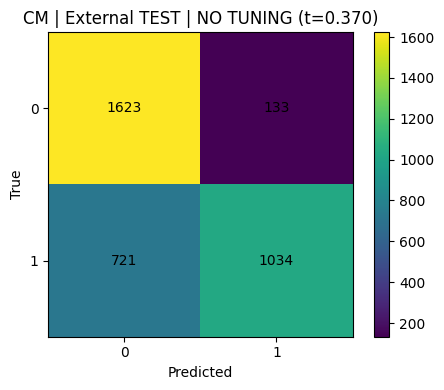

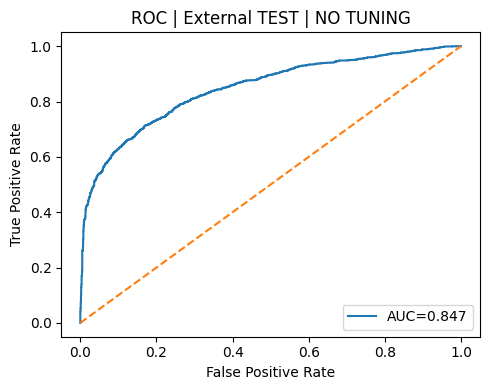

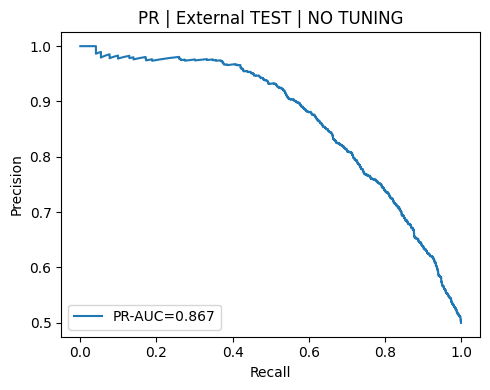

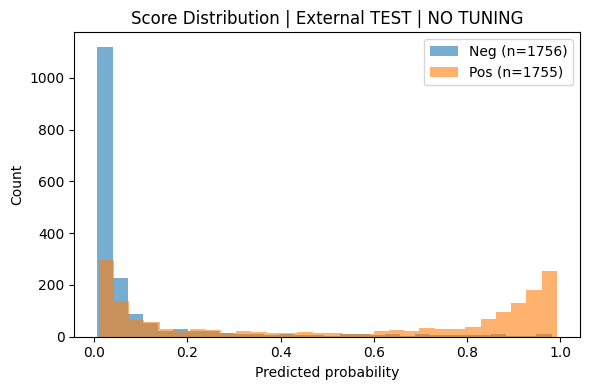

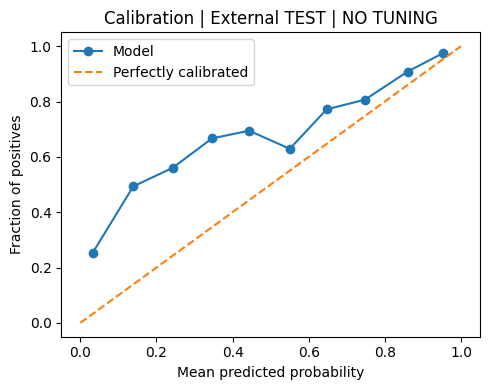

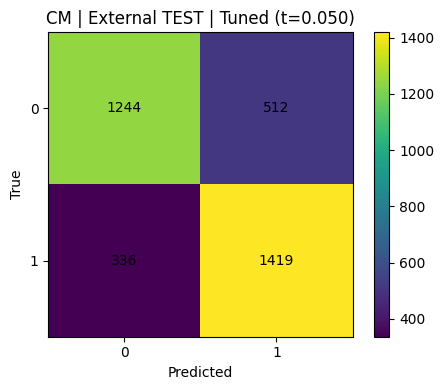

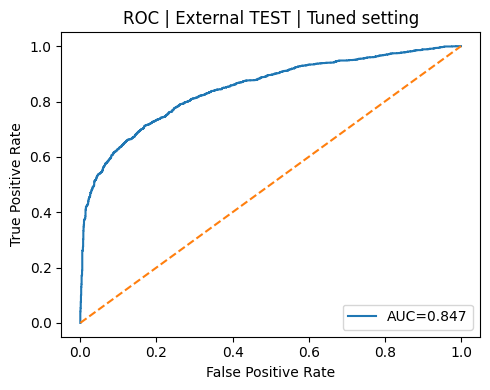

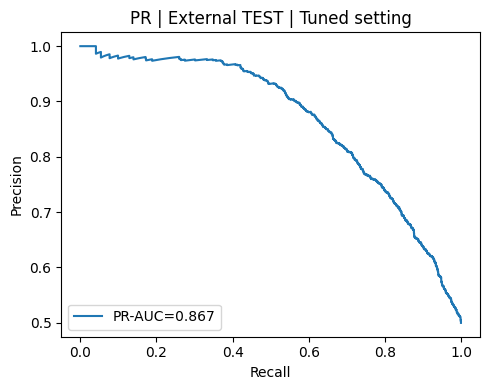

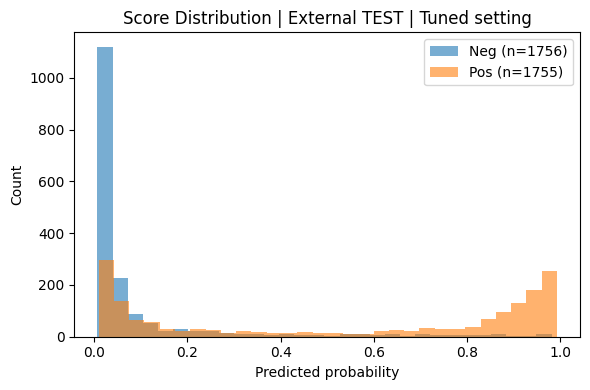

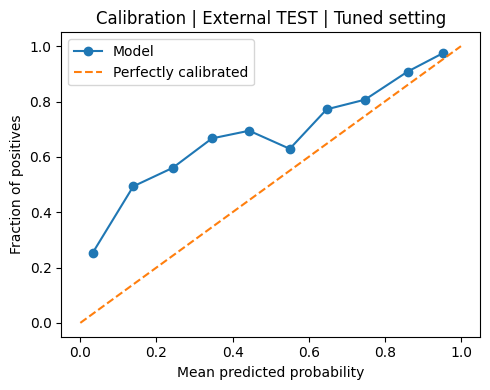

[Saved figures to] C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\Generalization_check\result


In [ ]:
y_test = test_df["has_pneumo"].to_numpy().astype(int)
p_test = test_df["p_calibrated"].to_numpy().astype(float)

prefix = "external_test_no_tuning"

plot_confusion_matrix(
    y_test, p_test, thr,
    title=f"CM | External TEST | NO TUNING (t={thr:.3f})",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_cm.png")
)

plot_roc(
    y_test, p_test,
    title="ROC | External TEST | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_roc.png")
)

plot_pr(
    y_test, p_test,
    title="PR | External TEST | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_pr.png")
)

plot_prob_hist(
    y_test, p_test,
    title="Score Distribution | External TEST | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_score_hist.png")
)

plot_calibration(
    y_test, p_test,
    title="Calibration | External TEST | NO TUNING",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_calibration.png")
)

prefix = "external_test_tuned_recall80"

plot_confusion_matrix(
    y_test, p_test, t_r80,
    title=f"CM | External TEST | Tuned (t={t_r80:.3f})",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_cm.png")
)

plot_roc(
    y_test, p_test,
    title="ROC | External TEST | Tuned setting",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_roc.png")
)

plot_pr(
    y_test, p_test,
    title="PR | External TEST | Tuned setting",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_pr.png")
)

plot_prob_hist(
    y_test, p_test,
    title="Score Distribution | External TEST | Tuned setting",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_score_hist.png")
)

plot_calibration(
    y_test, p_test,
    title="Calibration | External TEST | Tuned setting",
    save_path=os.path.join(SAVE_DIR, f"{prefix}_calibration.png")
)

print("[Saved figures to]", SAVE_DIR)